In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking local storage...
Train and Eval Data are already in local storage.

Loading Patient Paths from /content/local_dataset...
Found 1400 Train patients.
Found 276 Eval (Test) patients.

STAGE 1: Training CNN-GRU...
Epoch 1/30
    760/Unknown 81s 98ms/step - accuracy: 0.7058 - loss: 0.5876
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
760/760 ━━━━━━━━━━━━━━━━━━━━ 86s 105ms/step - accuracy: 0.7059 - loss: 0.5876 - val_accuracy: 0.7658 - val_loss: 0.4686 - learning_rate: 3.0000e-05
Epoch 2/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.7961 - loss:

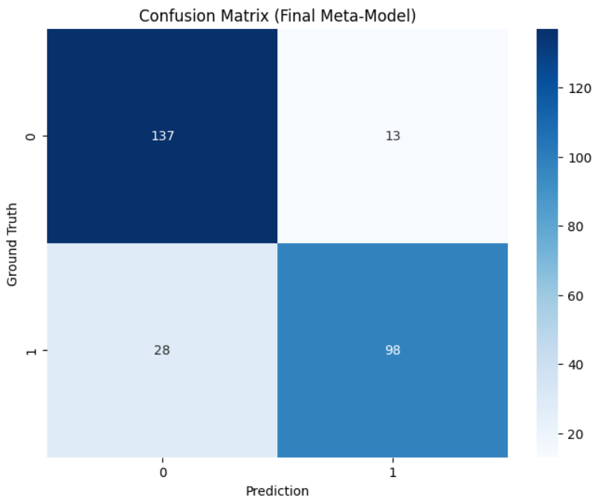

In [ ]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import time
from tqdm import tqdm

def force_remount():
    print("\n Detected Drive disconnection. Attempting to remount...")
    try:
        drive.flush_and_unmount()
    except:
        pass
    time.sleep(5)
    drive.mount('/content/drive', force_remount=True)
    print("Drive remounted successfully.\n")

try:
    drive.mount('/content/drive')
except:
    pass

DRIVE_BASE_DIR = '/content/drive/MyDrive/preprocessing_v2'
MODEL_SAVE_DIR = '/content/drive/MyDrive/models_v2_paper'
LOCAL_BASE_DIR = '/content/local_dataset'

print("Checking local storage...")

def get_total_files(src):
    total = 0
    for root, dirs, files in os.walk(src):
        total += len(files)
    return total

def robust_copy_with_progress(src, dst, pbar):
    if not os.path.exists(dst):
        os.makedirs(dst)

    while True:
        try:
            items = os.listdir(src)
            break
        except OSError as e:
            if "Transport endpoint" in str(e) or "Input/output" in str(e):
                force_remount()
            else:
                raise e

    for item in items:
        s = os.path.join(src, item)
        d = os.path.join(dst, item)

        while True:
            try:
                is_dir = os.path.isdir(s)
                break
            except OSError as e:
                if "Transport endpoint" in str(e) or "Input/output" in str(e):
                    force_remount()
                else:
                    raise e

        if is_dir:
            robust_copy_with_progress(s, d, pbar)
        else:
            if not os.path.exists(d):
                copied = False
                while not copied:
                    try:
                        shutil.copy2(s, d)
                        copied = True
                        pbar.update(1)
                    except OSError as e:
                        if "Transport endpoint" in str(e) or "Input/output" in str(e):
                            force_remount()
                        else:
                            print(f"\n Skipped {s} due to error: {e}")
                            break
            else:
                pbar.update(1)

def setup_local_data():
    train_local = os.path.join(LOCAL_BASE_DIR, 'train')
    eval_local = os.path.join(LOCAL_BASE_DIR, 'eval')

    if not os.path.exists(train_local) or not os.path.exists(eval_local):
        print(" Copying Train and Eval data safely to Colab Local Storage...")
        total_files = get_total_files(DRIVE_BASE_DIR)

        with tqdm(total=total_files, desc="Copying Data to SSD", unit="file") as pbar:
            robust_copy_with_progress(DRIVE_BASE_DIR, LOCAL_BASE_DIR, pbar)

        print("\n Data successfully copied to local storage!")
    else:
        print(" Train and Eval Data are already in local storage.")

    return LOCAL_BASE_DIR

ACTIVE_BASE_DIR = setup_local_data()

INPUT_SHAPE = (19, 6000)
MAX_WINDOWS = 30

def build_tcn_first_stage():

    inputs = layers.Input(shape=INPUT_SHAPE)

    x = layers.Permute((2,1))(inputs)

    x = layers.Conv1D(64,5,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(256,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Dropout(0.3)(x)

    x = layers.GRU(64, return_sequences=True)(x)

    attention = layers.Attention()([x,x])
    x = layers.GlobalAveragePooling1D()(attention)

    x = layers.Dense(32,activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1,activation='sigmoid')(x)

    model = models.Model(inputs,outputs,name="CNN_GRU_Window_Model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print(f"\n Loading Patient Paths from {ACTIVE_BASE_DIR}...")

train_patients = []
test_patients = []

for cls_name, label in [('normal',0),('abnormal',1)]:
    dir_path = os.path.join(ACTIVE_BASE_DIR,'train',cls_name)
    if os.path.exists(dir_path):
        for f in sorted(os.listdir(dir_path)):
            if f.endswith('.npy'):
                train_patients.append((os.path.join(dir_path,f),label))

for cls_name, label in [('normal',0),('abnormal',1)]:
    dir_path = os.path.join(ACTIVE_BASE_DIR,'eval',cls_name)
    if os.path.exists(dir_path):
        for f in sorted(os.listdir(dir_path)):
            if f.endswith('.npy'):
                test_patients.append((os.path.join(dir_path,f),label))

print(f" Found {len(train_patients)} Train patients.")
print(f" Found {len(test_patients)} Eval (Test) patients.")

tcn_train_patients, tcn_val_patients = train_test_split(
    train_patients,
    test_size=0.1,
    random_state=42,
    stratify=[p[1] for p in train_patients]
)

def window_generator(patient_list, shuffle_patients=True):

    local_list = patient_list.copy()

    if shuffle_patients:
        np.random.shuffle(local_list)

    for path,label in local_list:

        try:
            windows = np.load(path)

            for w in windows:
                yield w,label

            del windows

        except:
            continue

def create_tf_dataset(patient_list,batch_size=32,shuffle=True):

    ds = tf.data.Dataset.from_generator(
        lambda: window_generator(patient_list,shuffle),
        output_signature=(
            tf.TensorSpec(shape=INPUT_SHAPE,dtype=tf.float32),
            tf.TensorSpec(shape=(),dtype=tf.int32)
        )
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("\n STAGE 1: Training CNN-GRU...")

train_ds = create_tf_dataset(tcn_train_patients,batch_size=32,shuffle=True)
val_ds = create_tf_dataset(tcn_val_patients,batch_size=32,shuffle=False)

model = build_tcn_first_stage()

os.makedirs(MODEL_SAVE_DIR,exist_ok=True)

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_SAVE_DIR,'best_cnn_gru.keras'),
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )

]

model.fit(train_ds,validation_data=val_ds,epochs=30,callbacks=callbacks,verbose=1)

def extract_advanced_features(net,windows_array):

    probs = net.predict(windows_array,verbose=0).flatten()

    if len(probs) < MAX_WINDOWS:
        raw_probs = np.pad(probs,(0,MAX_WINDOWS-len(probs)),'constant')
    else:
        raw_probs = probs[:MAX_WINDOWS]

    if len(probs) > 0:

        f_max = np.max(probs)
        f_mean = np.mean(probs)
        f_std = np.std(probs)
        f_median = np.median(probs)

    else:
        f_max = f_mean = f_std = f_median = 0.0

    f_min = np.min(probs)
    f_var = np.var(probs)
    f_q25 = np.percentile(probs,25)
    f_q75 = np.percentile(probs,75)

    return np.concatenate([
        [f_max,f_mean,f_std,f_median,f_min,f_var,f_q25,f_q75],
        raw_probs
    ])

print("\n STAGE 2: Extracting Meta-Features...")

X_meta_train = []
y_meta_train = []

for path,label in tqdm(train_patients):

    try:

        windows = np.load(path)

        X_meta_train.append(
            extract_advanced_features(model,windows)
        )

        y_meta_train.append(label)

        del windows

    except:
        continue

X_meta_test = []
y_meta_test = []

for path,label in tqdm(test_patients):

    try:

        windows = np.load(path)

        X_meta_test.append(
            extract_advanced_features(model,windows)
        )

        y_meta_test.append(label)

        del windows

    except:
        continue

print("\n Training XGBoost Meta-Model...")

xgb_model = xgb.XGBClassifier(

    max_depth=6,
    learning_rate=0.01,
    n_estimators=1200,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=1.5,
    eval_metric='auc'

)

xgb_model.fit(np.array(X_meta_train),np.array(y_meta_train))

xgb_model.save_model(
    os.path.join(MODEL_SAVE_DIR,'xgboost_meta_model.json')
)

print("\n"+"="*60)
print(" TRUE CLINICAL EVALUATION (DEFAULT THRESHOLD 0.5)")
print("="*60)

y_pred = xgb_model.predict(np.array(X_meta_test))

y_proba = xgb_model.predict_proba(np.array(X_meta_test))[:,1]

print(f" Final Accuracy: {accuracy_score(y_meta_test,y_pred)*100:.2f}%")

print(f" Final ROC AUC: {roc_auc_score(y_meta_test,y_proba):.4f}\n")

print(classification_report(y_meta_test,y_pred))

cm = confusion_matrix(y_meta_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title('Confusion Matrix (Final Meta-Model)')

plt.xlabel('Prediction')

plt.ylabel('Ground Truth')

plt.savefig(
    os.path.join(MODEL_SAVE_DIR,'confusion_matrix_final.png'),
    dpi=300
)

plt.show()